In [ ]:
import numpy as np
import pandas as pd

In [ ]:
import kagglehub

# Downloading latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

100%|██████████| 211k/211k [00:00<00:00, 73.6MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uciml/sms-spam-collection-dataset/versions/1


In [ ]:
import os

In [ ]:
df = pd.read_csv(os.path.join(path, "spam.csv"), encoding='latin1')

In [ ]:
df.sample(5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
1735,ham,Why tired what special there you had,NaN,NaN,NaN
3940,spam,"Free Msg: get Gnarls Barkleys \Crazy\"" rington...",NaN,NaN,NaN
2540,ham,"They said if its gonna snow, it will start aro...",NaN,NaN,NaN
2890,ham,"Yeah there's quite a bit left, I'll swing by t...",NaN,NaN,NaN
234,spam,Text & meet someone sexy today. U can find a d...,NaN,NaN,NaN


In [ ]:
# checking the shape of the dataframe
df.shape

(5572, 5)

**Steps we are going to take:**

1. Data cleaning
2. EDA (Exploratory Data Analysis)
3. Text Preprocessing
4. Model building
5. Evaluation
6. Improvement
7. Website
8. Deployment

***1. DATA CLEANING***

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


***Observation*** **:**

Only the first two columns (**v1** and **v2**) contain meaningful data for our analysis.
The remaining three columns (**Unnamed: 2**, **Unnamed: 3**, and **Unnamed: 4**) contain mostly null values and are **irrelevant**.

**Therefore, we will drop these three unnecessary columns.**

In [ ]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [ ]:
df.sample(5)

,v1,v2
1794,ham,How much i gave to you. Morning.
2330,ham,Long beach lor. Expected... U having dinner now?
2860,ham,I am not at all happy with what you saying or ...
1301,ham,I tot u reach liao. He said t-shirt.
3895,spam,tells u 2 call 09066358152 to claim å£5000 pri...


**Note:**

Since the column names v1 and v2 are not very descriptive, we rename them to **'target'** and **'text'** respectively

In [ ]:
df.rename(columns={'v1':'target','v2':'text'},inplace=True)

In [ ]:
df.sample(5)

,target,text
2322,ham,Should I be stalking u?
5172,ham,"Aight, text me tonight and we'll see what's up"
799,ham,"\Gimme a few\"" was &lt;#&gt; minutes ago"""
313,ham,"Hi the way I was with u 2day, is the normal wa..."
5023,ham,Where you. What happen


**Note** **:**

We use **LabelEncoder** to convert the categorical labels (*ham* and *spam*) into numerical form.
This transformation is necessary because machine learning models work with numbers, not text.
After encoding, the new column 'target' will contain ***0 for ham*** and ***1 for spam***.

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder = LabelEncoder()

In [ ]:
df['target'] = encoder.fit_transform(df['target'])

In [ ]:
df.sample(5)

,target,text
424,0,Send this to ur friends and receive something ...
1511,0,Oops sorry. Just to check that you don't mind ...
1195,1,You have 1 new voicemail. Please call 08719181503
4572,1,\URGENT! This is the 2nd attempt to contact U!...
3282,0,Hey tmr maybe can meet you at yck


We will now check for missing values in the dataset.

In [ ]:
df.isnull().sum()

,0
target,0
text,0


We will now check if there are Duplicate values in the dataset

In [ ]:
print("Number of Duplicate values: ",df.duplicated().sum())

Number of Duplicate values:  403


**Note** **:**

As because we find 403 duplicate rows, we remove them from our dataframe keeping only their first appearance

In [ ]:
df = df.drop_duplicates(keep='first')

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.shape

(5169, 2)

***2. EDA (Exploratory Data Analysis)***

In [ ]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['target'].value_counts()

,count
target,
0,4516
1,653


In [ ]:
import matplotlib.pyplot as plt

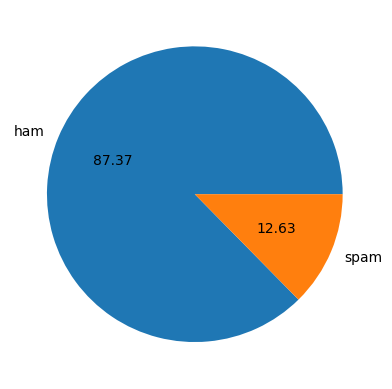

In [ ]:
plt.pie(df['target'].value_counts(), labels=['ham','spam'],autopct="%0.2f")
plt.show()

***Note:***

We see that the **Data is imbalanced**

In [ ]:
import nltk

In [ ]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [ ]:
df['char_count']=df['text'].apply(len)

In [ ]:
df.head()

,target,text,char_count
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [ ]:
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
df['word_count']=df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

In [ ]:
df.head()

,target,text,char_count,word_count
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [ ]:
df['sent_count']=df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [ ]:
df.sample(5)

,target,text,char_count,word_count,sent_count
2481,0,K.:)do it at evening da:)urgent:),33,13,1
3622,0,"Damn, poor zac doesn't stand a chance",37,9,1
4789,0,Yup. Izzit still raining heavily cos i'm in e ...,68,18,2
5413,0,Nite nite pocay wocay luv u more than n e thin...,81,17,1
3616,0,Sorry sent blank msg again. Yup but trying 2 d...,74,16,2


In [ ]:
df[['char_count','word_count','sent_count']].describe()

,char_count,word_count,sent_count
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
df[df['target']==0][['char_count','word_count','sent_count']].describe() # ham messages analysis

,char_count,word_count,sent_count
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
df[df['target']==1][['char_count','word_count','sent_count']].describe() # spam messages analysis

,char_count,word_count,sent_count
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [ ]:
import seaborn as sns

<Axes: xlabel='char_count', ylabel='Count'>

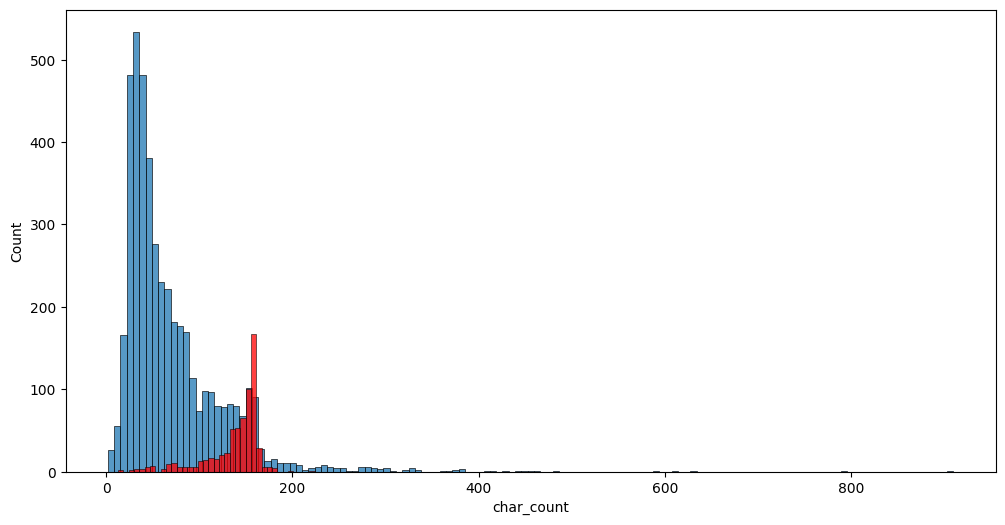

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['char_count'])
sns.histplot(df[df['target'] == 1]['char_count'],color='red')

<Axes: xlabel='word_count', ylabel='Count'>

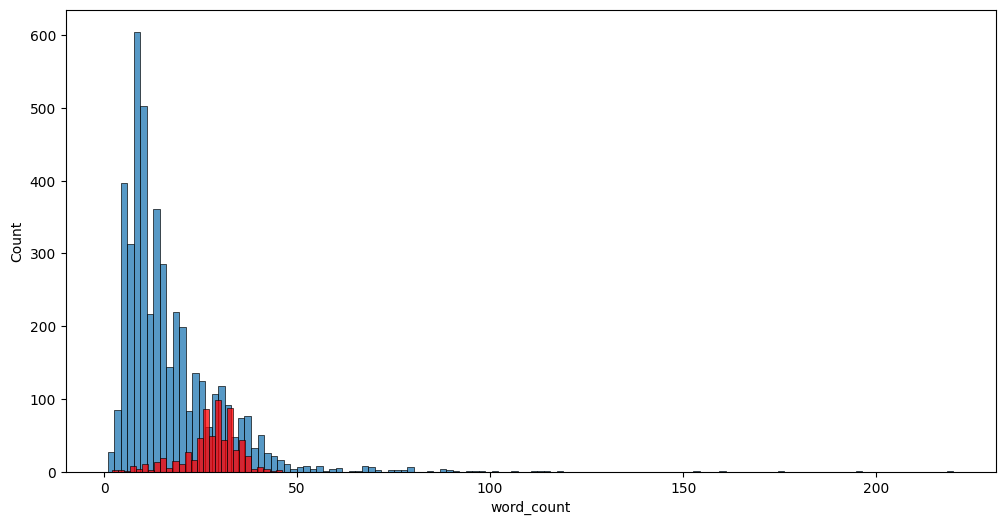

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['word_count'])
sns.histplot(df[df['target'] == 1]['word_count'],color='red')

<Axes: xlabel='sent_count', ylabel='Count'>

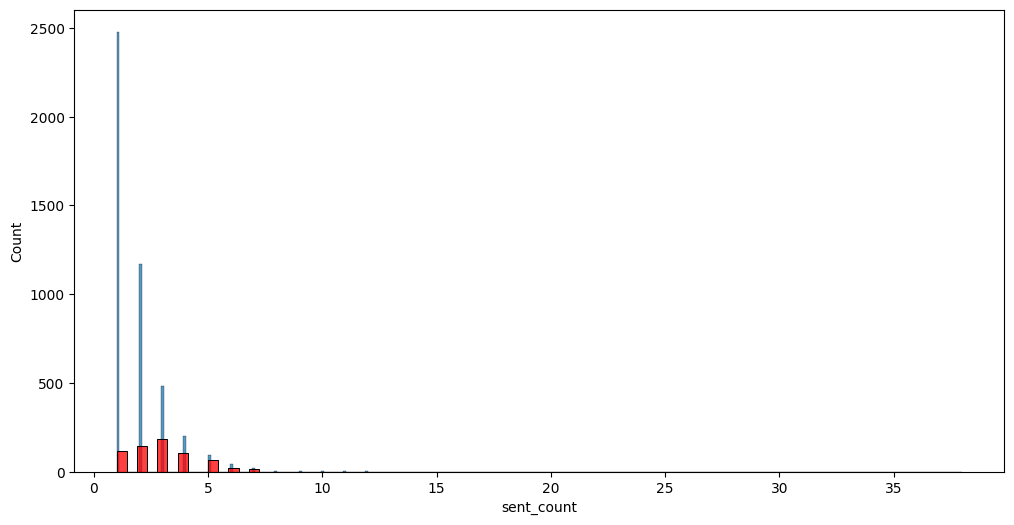

In [ ]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0]['sent_count'])
sns.histplot(df[df['target'] == 1]['sent_count'],color='red')

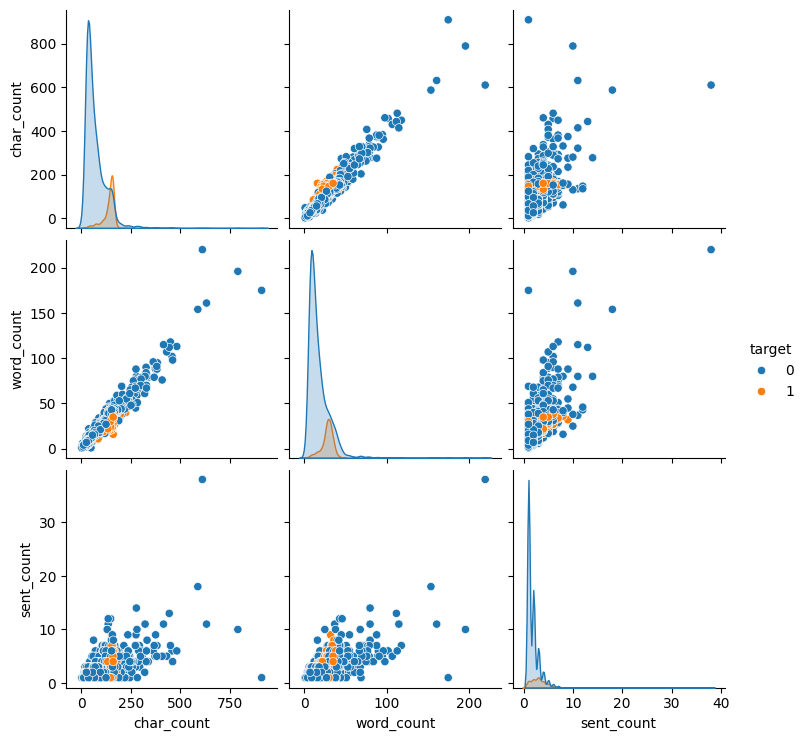

In [ ]:
sns.pairplot(df,hue='target')

<Axes: >

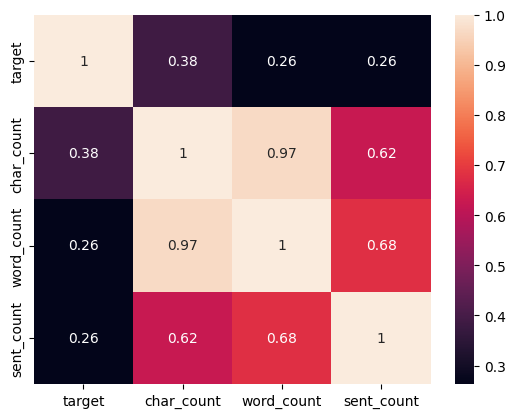

In [ ]:
sns.heatmap(df.select_dtypes(include=['number']).corr(),annot=True)

***3. Data Preprocessing***
      
  *   Lower Case
  *   Tokenization
  *   Removing special charaters
  *   Removing stop words and punctuations
  *   Stemming

In [ ]:
def transform_text(text):
    from nltk.corpus import stopwords
    import string
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))


    return " ".join(y)

In [ ]:
import nltk
nltk.download('stopwords')
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
transform_text("I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


'gon na home soon want talk stuff anymor tonight k cri enough today'

In [ ]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loving')

'love'

In [ ]:
df['transformed_text'] = df['text'].apply(transform_text)

In [ ]:
df['text'][1628]
df['transformed_text'][1628]

'ye princess want make happi'

In [ ]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [ ]:
spam_wc = wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep=" "))

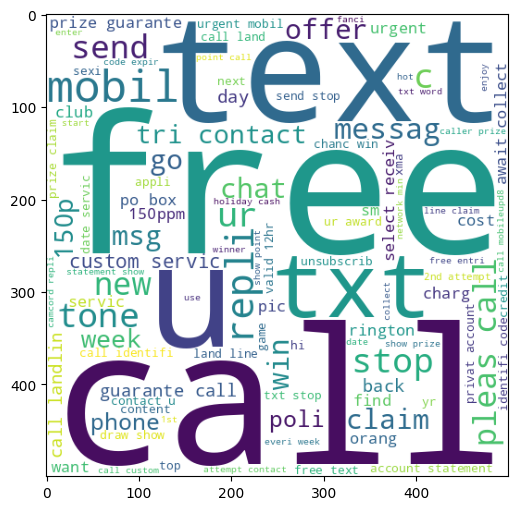

In [ ]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [ ]:
ham_wc = wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep=" "))

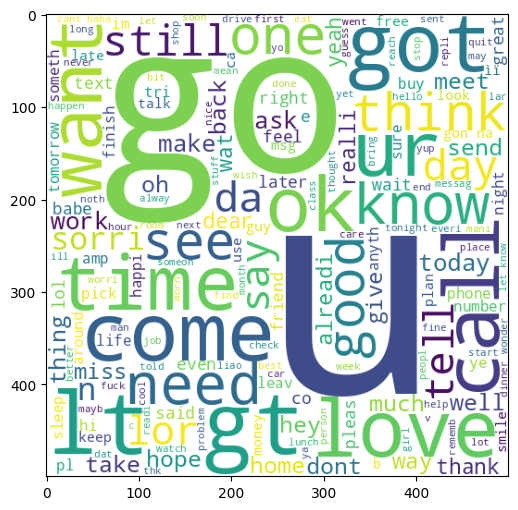

In [ ]:
plt.figure(figsize=(15,6))
plt.imshow(ham_wc)

In [ ]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [ ]:
len(spam_corpus)

9939

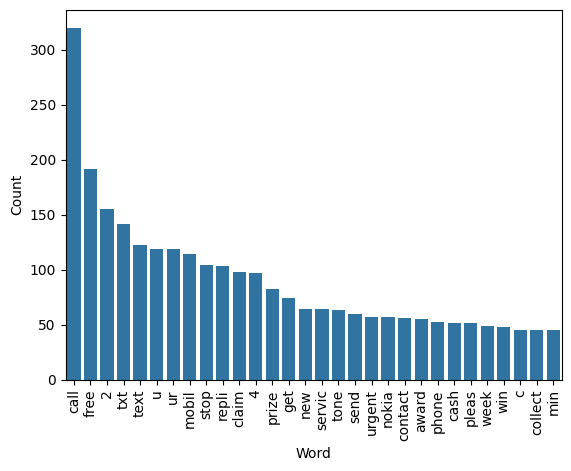

In [ ]:
from collections import Counter
spam_words_df = pd.DataFrame(Counter(spam_corpus).most_common(30), columns=['Word', 'Count'])
sns.barplot(x='Word', y='Count', data=spam_words_df)
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
    for word in msg.split():
        ham_corpus.append(word)

In [ ]:
len(ham_corpus)

35404

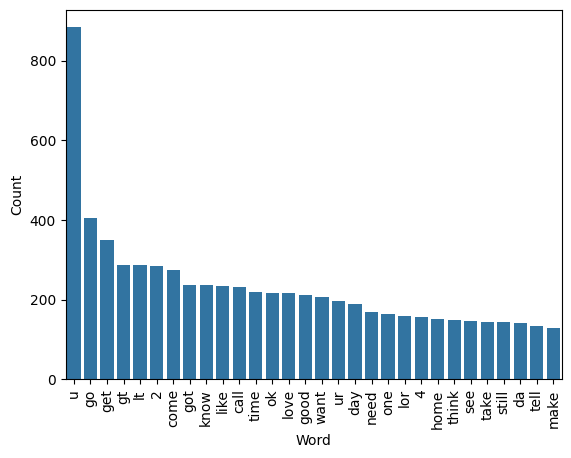

In [ ]:
ham_words_df = pd.DataFrame(Counter(ham_corpus).most_common(30), columns=['Word', 'Count'])
sns.barplot(x='Word', y='Count', data=ham_words_df)
plt.xticks(rotation='vertical')
plt.show()

***4. Model Building***

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
cv = CountVectorizer()

In [ ]:
X=cv.fit_transform(df['transformed_text']).toarray()

In [ ]:
X.shape

(5169, 6708)

In [ ]:
y = df['target'].values

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
def test_all_naive_bayes(X_train,y_train,X_test,y_test):
  from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
  from sklearn.metrics import accuracy_score,confusion_matrix,precision_score
  gnb = GaussianNB()
  mnb = MultinomialNB()
  bnb = BernoulliNB()

  gnb.fit(X_train,y_train)
  y_pred1 = gnb.predict(X_test)

  mnb.fit(X_train,y_train)
  y_pred2 = mnb.predict(X_test)

  bnb.fit(X_train,y_train)
  y_pred3 = bnb.predict(X_test)

  print('Gaussian Naive Bayes Evaluation Metrics')
  print(accuracy_score(y_test,y_pred1))
  print(confusion_matrix(y_test,y_pred1))
  print(precision_score(y_test,y_pred1))

  print('Multinomial Naive Bayes Evaluation Metrics')
  print(accuracy_score(y_test,y_pred2))
  print(confusion_matrix(y_test,y_pred2))
  print(precision_score(y_test,y_pred2))

  print('Bernoulli Naive Bayes Evaluation Metrics')
  print(accuracy_score(y_test,y_pred3))
  print(confusion_matrix(y_test,y_pred3))
  print(precision_score(y_test,y_pred3))

**Performance of Naive Bayes while using Count Vectorizer**

In [ ]:
test_all_naive_bayes(X_train,y_train,X_test,y_test)

Gaussian Naive Bayes Evaluation Metrics
0.8800773694390716
[[792 104]
 [ 20 118]]
0.5315315315315315
Multinomial Naive Bayes Evaluation Metrics
0.9642166344294004
[[871  25]
 [ 12 126]]
0.8344370860927153
Bernoulli Naive Bayes Evaluation Metrics
0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


**Now Testing model Performance using TF-IDF Vectorizer**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidf = TfidfVectorizer()

In [ ]:
X = tfidf.fit_transform(df['transformed_text']).toarray()

In [ ]:
y = df['target'].values

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
y_train.shape

(4135,)

In [ ]:
y_test.shape

(1034,)

In [ ]:
test_all_naive_bayes(X_train,y_train,X_test,y_test)

Gaussian Naive Bayes Evaluation Metrics
0.8762088974854932
[[793 103]
 [ 25 113]]
0.5231481481481481
Multinomial Naive Bayes Evaluation Metrics
0.9593810444874274
[[896   0]
 [ 42  96]]
1.0
Bernoulli Naive Bayes Evaluation Metrics
0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [ ]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
mnb = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

In [ ]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [ ]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    from sklearn.metrics import accuracy_score,precision_score
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [ ]:
# train_classifier(svc,X_train,y_train,X_test,y_test)

In [ ]:
# accuracy_scores = []
# precision_scores = []

# for name,clf in clfs.items():

#     current_accuracy,current_precision = train_classifier(clf, X_train,y_train,X_test,y_test)

#     print("For ",name)
#     print("Accuracy - ",current_accuracy)
#     print("Precision - ",current_precision)

#     accuracy_scores.append(current_accuracy)
#     precision_scores.append(current_precision)

In [ ]:
# performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [ ]:
# performance_df

In [ ]:
# performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [ ]:
# performance_df1

In [ ]:
# sns.catplot(x = 'Algorithm', y='value',
#                hue = 'variable',data=performance_df1, kind='bar',height=5)
# plt.ylim(0.5,1.0)
# plt.xticks(rotation='vertical')
# plt.show()

In [ ]:
tfidf_2 = TfidfVectorizer(max_features=3000)

In [ ]:
X2 = tfidf_2.fit_transform(df['transformed_text']).toarray()

In [ ]:
X2_train,X2_test,y_train,y_test = train_test_split(X2,y,test_size=0.2,random_state=2)

In [ ]:
accuracy_scores2 = []
precision_scores2 = []

for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, X2_train,y_train,X2_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores2.append(current_accuracy)
    precision_scores2.append(current_precision)

performance_df2 = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores2,'Precision':precision_scores2}).sort_values('Precision',ascending=False)

For  SVC
Accuracy -  0.9758220502901354
Precision -  0.9747899159663865
For  KN
Accuracy -  0.9052224371373307
Precision -  1.0
For  NB
Accuracy -  0.9709864603481625
Precision -  1.0
For  DT
Accuracy -  0.9332688588007737
Precision -  0.8415841584158416
For  LR
Accuracy -  0.9555125725338491
Precision -  0.96
For  RF
Accuracy -  0.9738878143133463
Precision -  0.9826086956521739
For  AdaBoost
Accuracy -  0.9216634429400387
Precision -  0.8202247191011236
For  BgC
Accuracy -  0.9584139264990329
Precision -  0.8682170542635659
For  ETC
Accuracy -  0.9748549323017408
Precision -  0.9745762711864406
For  GBDT
Accuracy -  0.9506769825918762
Precision -  0.9306930693069307
For  xgb
Accuracy -  0.9680851063829787
Precision -  0.9487179487179487


In [ ]:
import pandas as pd

performance_df = pd.DataFrame({
    "Algorithm": ["KN", "NB", "RF", "ETC", "SVC", "xgb", "LR", "GBDT", "BgC", "DT", "AdaBoost"],
    "Accuracy": [0.900387, 0.959381, 0.971954, 0.972921, 0.972921, 0.974855, 0.951644, 0.952611, 0.958414, 0.936170, 0.924565],
    "Precision": [1.000000, 1.000000, 1.000000, 0.982456, 0.974138, 0.951613, 0.940000, 0.923810, 0.862595, 0.846154, 0.840909]
})

# Rename columns in performance_df2 to avoid conflicts and distinguish them in the merged DataFrame
performance_df2_renamed = performance_df2.rename(columns={'Accuracy': 'Accuracy_TFIDF_max3000', 'Precision': 'Precision_TFIDF_max3000'})

# Merge the original performance_df with the renamed performance_df2
performance_df = performance_df.merge(performance_df2_renamed[['Algorithm', 'Accuracy_TFIDF_max3000', 'Precision_TFIDF_max3000']], on='Algorithm', how='left')

performance_df

,Algorithm,Accuracy,Precision,Accuracy_TFIDF_max3000,Precision_TFIDF_max3000
0,KN,0.900387,1.000000,0.905222,1.000000
1,NB,0.959381,1.000000,0.970986,1.000000
2,RF,0.971954,1.000000,0.973888,0.982609
3,ETC,0.972921,0.982456,0.974855,0.974576
4,SVC,0.972921,0.974138,0.975822,0.974790
5,xgb,0.974855,0.951613,0.968085,0.948718
6,LR,0.951644,0.940000,0.955513,0.960000
7,GBDT,0.952611,0.923810,0.950677,0.930693
8,BgC,0.958414,0.862595,0.958414,0.868217
9,DT,0.936170,0.846154,0.933269,0.841584


# Task
Apply MinMaxScaler to the TF-IDF features (X2), re-train and evaluate all classifiers using these scaled features, and store the new accuracy and precision scores.

## scale_features_and_reevaluate

### Subtask:
Apply MinMaxScaler to the TF-IDF features (X2), re-train and evaluate all classifiers using these scaled features, and store the new accuracy and precision scores.


**Reasoning**:
The subtask requires scaling the TF-IDF features (X2) using `MinMaxScaler`, then re-training and evaluating all classifiers with these scaled features. The first step is to import `MinMaxScaler` and initialize it, then apply it to `X2` to get `X_scaled`.



In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Instantiate MinMaxScaler
scaler = MinMaxScaler()

# Apply fit_transform to X2 features and store the result in X_scaled
X_scaled = scaler.fit_transform(X2)

# Split the X_scaled features and the target variable y into training and testing sets
X_train_scaled, X_test_scaled, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=2)

# Initialize lists to store accuracy and precision scores for scaled features
accuracy_scores_scaled = []
precision_scores_scaled = []

# Iterate through each classifier in the clfs dictionary and evaluate with scaled data
for name, clf in clfs.items():
    current_accuracy, current_precision = train_classifier(clf, X_train_scaled, y_train, X_test_scaled, y_test)

    print(f"For {name}")
    print(f"Accuracy - {current_accuracy}")
    print(f"Precision - {current_precision}")

    accuracy_scores_scaled.append(current_accuracy)
    precision_scores_scaled.append(current_precision)


For SVC
Accuracy - 0.9700193423597679
Precision - 0.9421487603305785
For KN
Accuracy - 0.9052224371373307
Precision - 0.9761904761904762
For NB
Accuracy - 0.9787234042553191
Precision - 0.9461538461538461
For DT
Accuracy - 0.9323017408123792
Precision - 0.8333333333333334
For LR
Accuracy - 0.9671179883945842
Precision - 0.9642857142857143
For RF
Accuracy - 0.9738878143133463
Precision - 0.9826086956521739
For AdaBoost
Accuracy - 0.9216634429400387
Precision - 0.8202247191011236
For BgC
Accuracy - 0.9584139264990329
Precision - 0.8682170542635659
For ETC
Accuracy - 0.9748549323017408
Precision - 0.9745762711864406
For GBDT
Accuracy - 0.9506769825918762
Precision - 0.9306930693069307
For xgb
Accuracy - 0.9680851063829787
Precision - 0.9487179487179487


**Reasoning**:
After evaluating all classifiers with the scaled TF-IDF features, the next step is to consolidate these results into a new DataFrame. This will allow for a clear comparison with previous results and further analysis.



In [ ]:
performance_df_scaled = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaled':accuracy_scores_scaled,'Precision_scaled':precision_scores_scaled}).sort_values('Precision_scaled',ascending=False)
performance_df_scaled

,Algorithm,Accuracy_scaled,Precision_scaled
5,RF,0.973888,0.982609
1,KN,0.905222,0.976190
8,ETC,0.974855,0.974576
4,LR,0.967118,0.964286
10,xgb,0.968085,0.948718
2,NB,0.978723,0.946154
0,SVC,0.970019,0.942149
9,GBDT,0.950677,0.930693
7,BgC,0.958414,0.868217
3,DT,0.932302,0.833333


**Reasoning**:
To compare the performance of classifiers with and without feature scaling, the newly generated `performance_df_scaled` should be merged with the existing `performance_df`. This will add columns for scaled accuracy and precision, allowing for a consolidated view of all results.



In [ ]:
performance_df = performance_df.merge(performance_df_scaled.rename(columns={'Accuracy_scaled': 'Accuracy_TFIDF_scaled', 'Precision_scaled': 'Precision_TFIDF_scaled'}), on='Algorithm', how='left')
performance_df

,Algorithm,Accuracy,Precision,Accuracy_TFIDF_max3000,Precision_TFIDF_max3000,Accuracy_TFIDF_scaled,Precision_TFIDF_scaled
0,KN,0.900387,1.000000,0.905222,1.000000,0.905222,0.976190
1,NB,0.959381,1.000000,0.970986,1.000000,0.978723,0.946154
2,RF,0.971954,1.000000,0.973888,0.982609,0.973888,0.982609
3,ETC,0.972921,0.982456,0.974855,0.974576,0.974855,0.974576
4,SVC,0.972921,0.974138,0.975822,0.974790,0.970019,0.942149
5,xgb,0.974855,0.951613,0.968085,0.948718,0.968085,0.948718
6,LR,0.951644,0.940000,0.955513,0.960000,0.967118,0.964286
7,GBDT,0.952611,0.923810,0.950677,0.930693,0.950677,0.930693
8,BgC,0.958414,0.862595,0.958414,0.868217,0.958414,0.868217
9,DT,0.936170,0.846154,0.933269,0.841584,0.932302,0.833333


## Summary:

### Data Analysis Key Findings
*   TF-IDF features (X2) were successfully scaled using `MinMaxScaler`, resulting in `X_scaled` for model training.
*   After scaling and re-training, the classifiers' performance was updated:
    *   Random Forest (RF) achieved the highest precision of 0.9826 and an accuracy of 0.9739.
    *   Naive Bayes (NB) followed with an accuracy of 0.9787 and precision of 0.9462.
    *   Support Vector Classifier (SVC) had an accuracy of 0.9700 and precision of 0.9421.
*   A new DataFrame, `performance_df_scaled`, was generated to store these updated metrics, and subsequently merged into the main `performance_df`, adding `Accuracy_TFIDF_scaled` and `Precision_TFIDF_scaled` columns for comprehensive comparison.

### Insights or Next Steps
*   Scaling TF-IDF features appears to have a notable impact on model performance, especially precision, for some algorithms, warranting a detailed comparison with unscaled TF-IDF and original features.
*   The consolidated `performance_df` now contains a rich set of evaluation metrics across different feature processing techniques, which is valuable for selecting the optimal model and feature engineering approach. The next step should involve a thorough comparative analysis of all performance metrics to determine the best performing model and feature set.


In [ ]:
import pickle
pickle.dump(tfidf_2,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))